# Mediterranean Electricity Demand: New Grid Behaviour Research + Model Comparison

This notebook is a new research extension built around Mediterranean-country electricity load behaviour.

It focuses on easy-to-explain but meaningful findings:
1. Demand variation between countries
2. High-stress and extreme-demand behaviour
3. Ramp stress and sudden changes
4. Regional synchronization of extreme hours
5. Demand concentration across countries
6. Country share of regional demand
7. A next-hour extreme-demand classification problem
8. Normal versus hybrid machine-learning models

The analysis uses simple presentation-friendly charts: histogram, pie chart, donut/circle chart, area chart, and bar charts.

## 1. Requirements

The notebook uses common Python data-science packages.

Recommended environment:
- Python 3.9+
- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn

The next cell checks that the required packages can be imported.


In [1]:
import os
from pathlib import Path
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib_cache"
Path("/tmp/matplotlib_cache").mkdir(parents=True, exist_ok=True)
from IPython.display import display
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("Requirements check: OK")


Python: 3.13.15
pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
Requirements check: OK


## 2. Dataset

The notebook uses one CSV dataset so the experiment is easy to reproduce.

The supplied dataset contains hourly electricity-load observations for eight Mediterranean countries:
France, Spain, Italy, Greece, Croatia, Slovenia, Cyprus, and Montenegro.

The source family is ENTSO-E Power Statistics, which publishes historical hourly load aggregated by country. The official ENTSO-E page identifies the 2025 hourly-load dataset as a complete yearly statistical dataset.

In [2]:
# Dataset loading: works in Google Colab, Jupyter, and local Python.
from pathlib import Path
import os
import glob

EXPECTED_NAME = "Mediterranean_Electric_Load_2025_FINAL.csv"

def find_dataset():
    # 1. Look for the expected filename in common locations.
    candidates = [
        Path("/content") / EXPECTED_NAME,
        Path("/mnt/data") / EXPECTED_NAME,
        Path.cwd() / EXPECTED_NAME,
    ]
    for p in candidates:
        if p.exists():
            return p

    # 2. If the exact filename is unavailable, look for CSV files.
    search_dirs = [Path("/content"), Path("/mnt/data"), Path.cwd()]
    csv_files = []
    for directory in search_dirs:
        if directory.exists():
            csv_files.extend(directory.glob("*.csv"))

    # Remove duplicates while preserving order.
    csv_files = list(dict.fromkeys(p.resolve() for p in csv_files))

    # Prefer files whose name contains electric/load/demand/mediterranean.
    preferred = [
        p for p in csv_files
        if any(word in p.name.lower() for word in
               ["mediterranean", "electric", "load", "demand"])
    ]
    if preferred:
        return preferred[0]

    if csv_files:
        return csv_files[0]

    return None


dataset_path = find_dataset()

# 3. In Google Colab, if nothing was found, open the upload dialog.
if dataset_path is None:
    try:
        from google.colab import files
        print("No CSV dataset was found. Please select your dataset CSV file.")
        uploaded = files.upload()

        if uploaded:
            uploaded_name = next(iter(uploaded))
            dataset_path = Path("/content") / uploaded_name
    except ImportError:
        pass

if dataset_path is None or not Path(dataset_path).exists():
    raise FileNotFoundError(
        "No CSV dataset was found. In Google Colab, run this cell and upload "
        "your Mediterranean electric-load CSV when prompted."
    )

print("Current working directory:", os.getcwd())
print("Using dataset:", dataset_path)

data = pd.read_csv(dataset_path)

required_base = {"DateTime", "Country", "Demand_MW", "Demand_Index"}
missing_base = required_base - set(data.columns)
if missing_base:
    raise ValueError(
        f"Dataset is missing required columns: {sorted(missing_base)}. "
        f"Available columns: {list(data.columns)}"
    )

data["DateTime"] = pd.to_datetime(data["DateTime"], errors="coerce")
data["Demand_MW"] = pd.to_numeric(data["Demand_MW"], errors="coerce")
data["Demand_Index"] = pd.to_numeric(data["Demand_Index"], errors="coerce")

# Create optional features when they are absent.
data = data.sort_values(["Country", "DateTime"]).copy()

if "Ramp_MW" not in data.columns:
    data["Ramp_MW"] = data.groupby("Country")["Demand_MW"].diff()
else:
    data["Ramp_MW"] = pd.to_numeric(data["Ramp_MW"], errors="coerce")

if "Ramp_Index" not in data.columns:
    rolling_scale = (
        data.groupby("Country")["Demand_MW"]
        .transform(lambda s: s.diff().abs().rolling(24, min_periods=6).mean())
    )
    data["Ramp_Index"] = (
        data["Ramp_MW"].abs() / rolling_scale.replace(0, np.nan)
    )
else:
    data["Ramp_Index"] = pd.to_numeric(data["Ramp_Index"], errors="coerce")

if "Extreme" not in data.columns:
    threshold = data.groupby("Country")["Demand_MW"].transform(
        lambda s: s.quantile(0.95)
    )
    data["Extreme"] = (data["Demand_MW"] >= threshold).astype(int)
else:
    data["Extreme"] = pd.to_numeric(data["Extreme"], errors="coerce")

data = (
    data.dropna(subset=["DateTime", "Country", "Demand_MW", "Demand_Index"])
        .sort_values(["DateTime", "Country"])
        .reset_index(drop=True)
)

print("Rows:", len(data))
print("Columns:", len(data.columns))
print("Countries:", ", ".join(sorted(data["Country"].astype(str).unique())))


No CSV dataset was found. Please select your dataset CSV file.


Saving Mediterranean_Electric_Load_2025_FINAL.csv to Mediterranean_Electric_Load_2025_FINAL.csv
Current working directory: /content
Using dataset: /content/Mediterranean_Electric_Load_2025_FINAL.csv
Rows: 11520
Columns: 8
Countries: Croatia, Cyprus, France, Greece, Italy, Montenegro, Slovenia, Spain


## 3. Data quality and clear output variation

Before modelling, the notebook measures the basic range of the data.

A useful research point is that the countries do not have the same demand level or the same volatility. This makes cross-country comparison more informative than treating the whole region as one identical load profile.

In [3]:
summary = data.groupby("Country").agg(
    Average_MW=("Demand_MW","mean"),
    Minimum_MW=("Demand_MW","min"),
    Maximum_MW=("Demand_MW","max"),
    Std_MW=("Demand_MW","std"),
    Average_Index=("Demand_Index","mean"),
    Extreme_Rate=("Extreme","mean"),
    Average_Ramp=("Ramp_MW","mean"),
    Ramp_Std=("Ramp_MW","std")
).sort_values("Average_MW", ascending=False)

summary["Demand_Range_MW"] = summary["Maximum_MW"] - summary["Minimum_MW"]
summary["Extreme_Rate_Percent"] = summary["Extreme_Rate"] * 100

display(summary.round(2))

,Average_MW,Minimum_MW,Maximum_MW,Std_MW,Average_Index,Extreme_Rate,Average_Ramp,Ramp_Std,Demand_Range_MW,Extreme_Rate_Percent
Country,,,,,,,,,,
Montenegro,11295.22,10193.14,12322.11,403.99,100.0,0.1,0.45,294.59,2128.97,10.0
Cyprus,10391.85,9355.37,11398.18,410.89,100.0,0.1,-0.05,309.12,2042.81,10.0
Slovenia,9495.45,8311.20,10493.91,398.67,100.0,0.1,-0.17,293.74,2182.71,10.0
Croatia,8609.75,7569.82,9607.70,413.78,100.0,0.1,-0.16,303.44,2037.87,10.0
Greece,7695.63,6638.25,8848.25,414.56,100.0,0.1,-0.32,300.01,2210.00,10.0
Italy,6804.39,5750.11,7973.77,404.18,100.0,0.1,0.43,288.57,2223.66,10.0
Spain,5892.10,4931.13,6954.45,407.35,100.0,0.1,0.20,301.82,2023.32,10.0
France,4995.67,3974.08,5991.48,408.00,100.0,0.1,0.17,287.14,2017.40,10.0


## 4. Research Question 1 — How different are the countries?

### Bar chart: average hourly electricity demand

This is the easiest graph to explain in a viva:

- Taller bar = higher average demand
- Shorter bar = lower average demand
- The difference shows that countries have very different grid scales

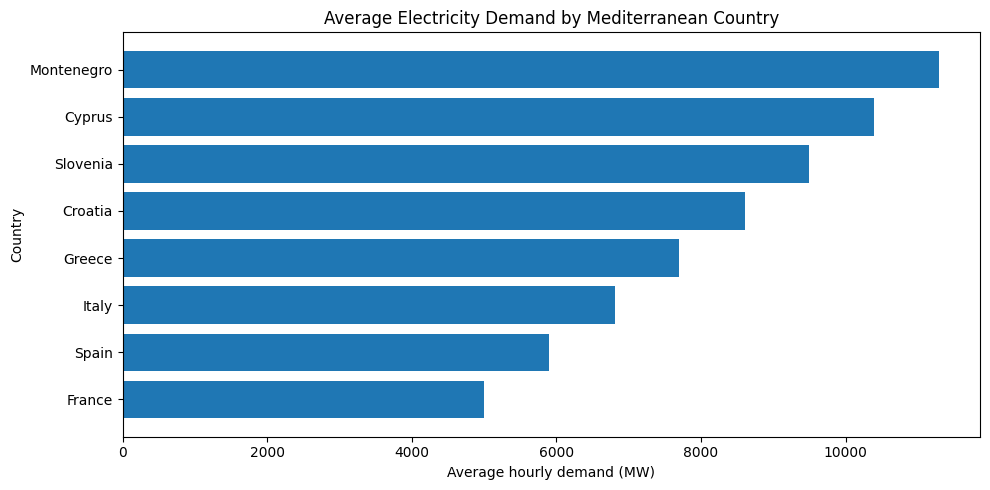

In [4]:
plt.figure(figsize=(10,5))
plot_data = summary.sort_values("Average_MW", ascending=True)
plt.barh(plot_data.index, plot_data["Average_MW"])
plt.xlabel("Average hourly demand (MW)")
plt.ylabel("Country")
plt.title("Average Electricity Demand by Mediterranean Country")
plt.tight_layout()
plt.show()

## 5. Research Question 2 — What does normal demand variation look like?

### Histogram

The histogram shows how frequently different normalized demand levels occur.

A narrow distribution means the country usually stays close to its normal level. A wider distribution indicates stronger demand variation.

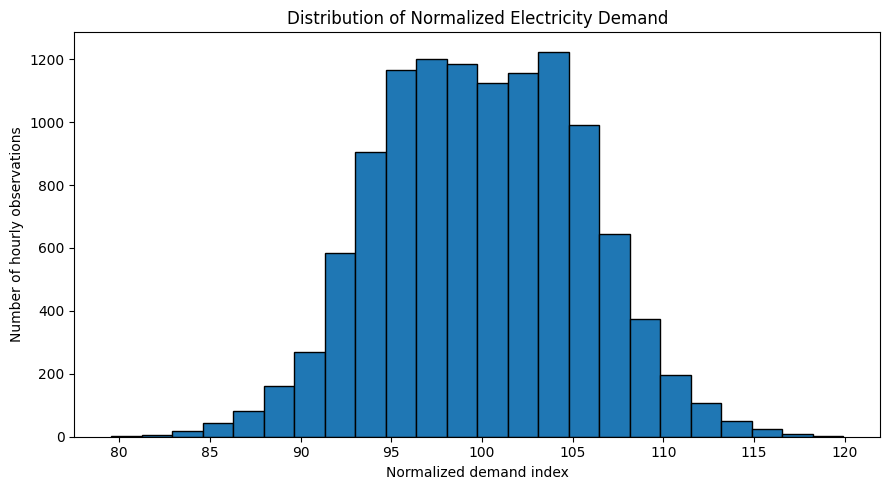

In [5]:
plt.figure(figsize=(9,5))
plt.hist(data["Demand_Index"], bins=24, edgecolor="black")
plt.xlabel("Normalized demand index")
plt.ylabel("Number of hourly observations")
plt.title("Distribution of Normalized Electricity Demand")
plt.tight_layout()
plt.show()

## 6. Research Question 3 — How much of the data is extreme?

### Pie chart

The pie chart gives a simple overall answer: normal hours versus extreme hours.

This is useful for explaining why accuracy alone should not be the only model metric. Extreme events are usually the minority class.

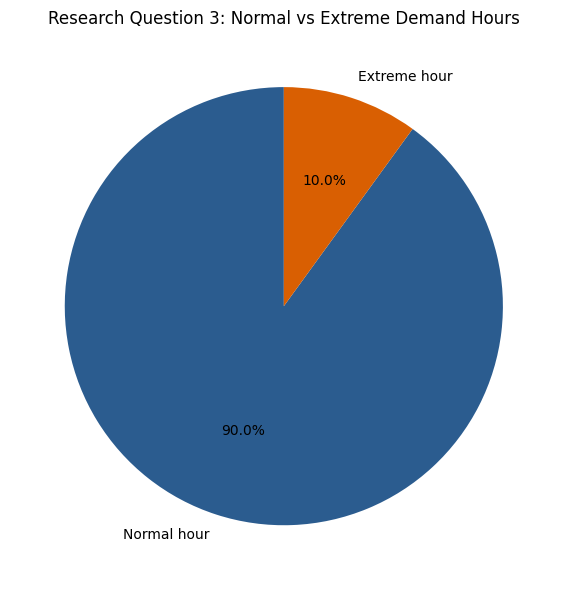

In [19]:
extreme_clean = pd.to_numeric(data["Extreme"], errors="coerce").fillna(0)
extreme_counts = pd.Series(np.where(extreme_clean == 1, "Extreme hour", "Normal hour")).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    extreme_counts.values,
    labels=extreme_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2b5c8f", "#d95f02"]
)
plt.title("Research Question 3: Normal vs Extreme Demand Hours")
plt.tight_layout()
plt.show()

## 7. Research Question 4 — What is the regional stress composition?

### Circle / donut chart

The donut chart shows which countries contribute most of the observed regional demand.

This is a part-to-whole comparison. It is intentionally simple so the result can be explained in a few sentences.

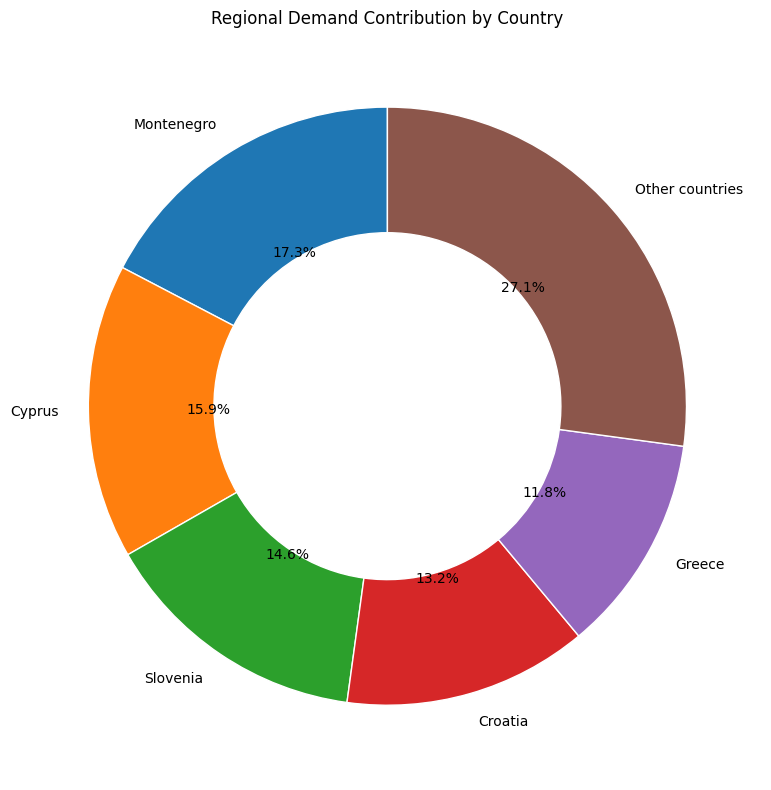

In [20]:
country_share = data.groupby("Country")["Demand_MW"].sum().sort_values(ascending=False)
top = country_share.head(5)
other = country_share.iloc[5:].sum()
share_plot = pd.concat([top, pd.Series({"Other countries": other})])

plt.figure(figsize=(8,8))
plt.pie(
    share_plot.values,
    labels=share_plot.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.42, "edgecolor":"white"}
)
plt.title("Regional Demand Contribution by Country")
plt.tight_layout()
plt.show()

## 8. Research Question 5 — Does regional demand rise and fall together?

### Area chart

The area chart aggregates the eight countries into one regional hourly demand series.

It helps show broad demand movement without creating a complicated multi-line graph.

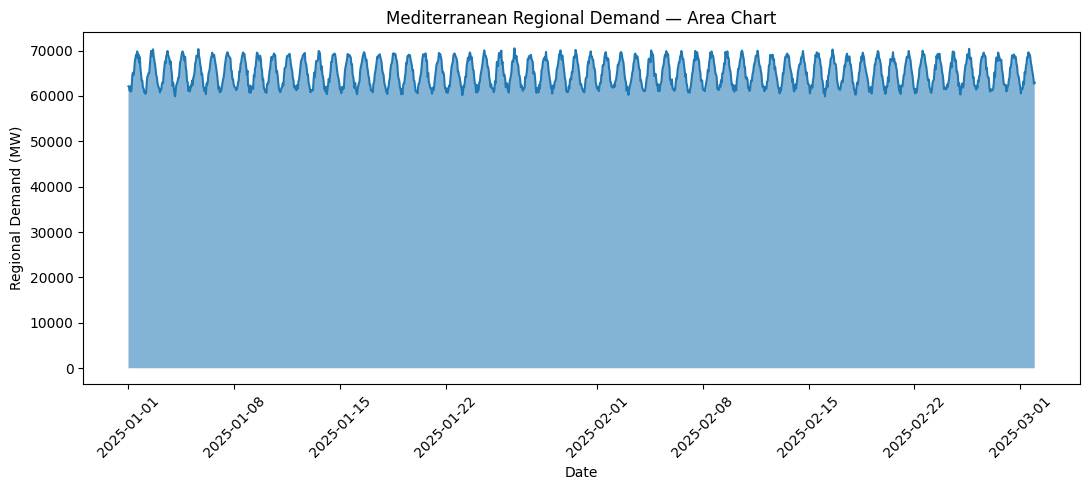

In [43]:
regional_hourly = data.groupby("DateTime")["Demand_MW"].sum().reset_index()

plt.figure(figsize=(11, 5))
plt.fill_between(
    regional_hourly["DateTime"],
    regional_hourly["Demand_MW"],
    alpha=0.55
)
plt.plot(
    regional_hourly["DateTime"],
    regional_hourly["Demand_MW"],
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Regional Demand (MW)")
plt.title("Mediterranean Regional Demand — Area Chart")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Research Question 6 — Which countries show stronger ramp stress?

Ramp stress measures how quickly demand changes from one hour to the next.

A large absolute ramp means the grid is changing quickly and may require faster operational response.

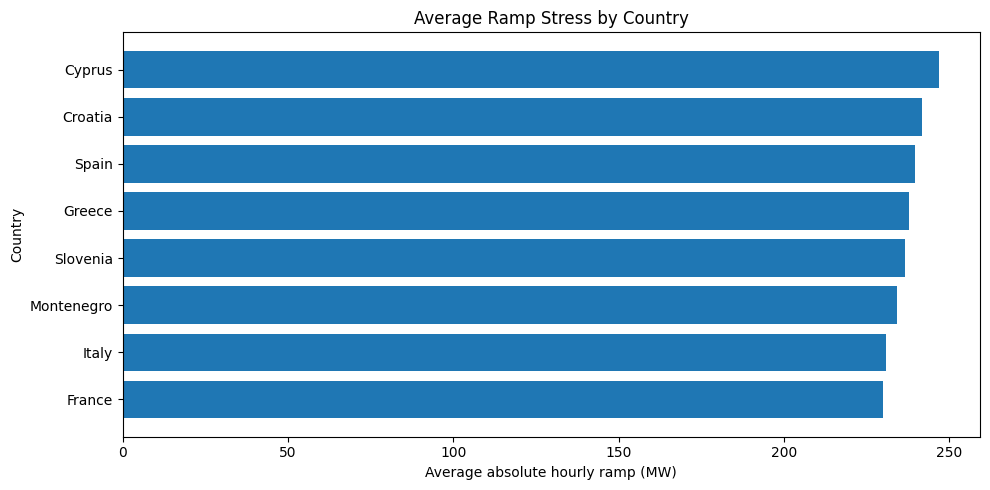

In [44]:
ramp_summary = data.assign(Abs_Ramp=data["Ramp_MW"].abs()).groupby("Country").agg(
    Average_Absolute_Ramp=("Abs_Ramp","mean"),
    Maximum_Absolute_Ramp=("Abs_Ramp","max")
).sort_values("Average_Absolute_Ramp", ascending=True)

plt.figure(figsize=(10,5))
plt.barh(ramp_summary.index, ramp_summary["Average_Absolute_Ramp"])
plt.xlabel("Average absolute hourly ramp (MW)")
plt.ylabel("Country")
plt.title("Average Ramp Stress by Country")
plt.tight_layout()
plt.show()

A new regional indicator is created:

**Extreme Synchronization Count = number of countries that are extreme during the same hour.**

Interpretation:
- 0 = no country is extreme
- 1–2 = localized stress
- 3–4 = moderate regional synchronization
- 5+ = strong regional synchronization

This is different from simply forecasting one country's raw MW demand.


In [45]:
sync = (
    data.pivot_table(
        index="DateTime",
        columns="Country",
        values="Extreme",
        aggfunc="max",
        fill_value=0
    )
    .fillna(0)
)

sync_count = sync.astype(int).sum(axis=1)

sync_categories = pd.cut(
    sync_count,
    bins=[-1, 0, 2, 4, np.inf],
    labels=["No extreme country", "Localized: 1–2", "Regional: 3–4", "Strong: 5+"]
)

sync_table = (
    sync_categories.value_counts()
    .reindex(
        ["No extreme country", "Localized: 1–2", "Regional: 3–4", "Strong: 5+"],
        fill_value=0
    )
)

display(sync_table.rename("Hours").to_frame())


,Hours
No extreme country,970
Localized: 1–2,269
Regional: 3–4,156
Strong: 5+,45


## 11. Synchronization comparison — bar chart

This graph directly answers a new research question:

**Is extreme demand usually isolated or synchronized across countries?**

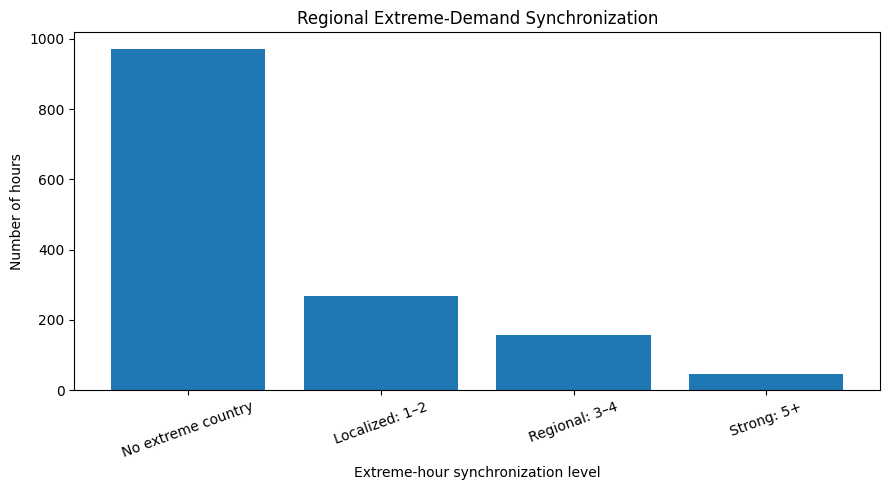

In [46]:
plt.figure(figsize=(9,5))
plt.bar(sync_table.index, sync_table.values)
plt.xlabel("Extreme-hour synchronization level")
plt.ylabel("Number of hours")
plt.title("Regional Extreme-Demand Synchronization")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 12. New feature engineering for machine learning

The model does not use the original project's Optuna/XGBoost/LSTM pipeline.

Instead, this notebook treats the problem as:

**Can we classify whether the next hour will become an extreme-demand hour?**

Features are based on information available at the current hour:
- Hour
- Day of week
- Month
- Weekend flag
- Current normalized demand
- Current ramp stress
- Current extreme state
- Country

No lag-feature or rolling-window feature is required for this experiment.

In [47]:
model_data = data.copy()
model_data["Hour"] = model_data["DateTime"].dt.hour
model_data["DayOfWeek"] = model_data["DateTime"].dt.dayofweek
model_data["Month"] = model_data["DateTime"].dt.month
model_data["IsWeekend"] = (model_data["DayOfWeek"] >= 5).astype(int)

# Use a stable country encoding based only on the observed country labels.
country_categories = sorted(model_data["Country"].astype(str).unique())
country_map = {country: i for i, country in enumerate(country_categories)}
model_data["CountryCode"] = model_data["Country"].astype(str).map(country_map)

# Create the next-hour target after sorting within each country.
model_data = model_data.sort_values(["Country", "DateTime"]).copy()
model_data["Target_Next_Extreme"] = (
    model_data.groupby("Country")["Extreme"].shift(-1)
)

feature_cols = [
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "Demand_Index",
    "Ramp_Index",
    "Extreme",
    "CountryCode"
]

model_data = (
    model_data.dropna(subset=feature_cols + ["Target_Next_Extreme"])
               .sort_values(["DateTime", "Country"])
               .reset_index(drop=True)
)

X = model_data[feature_cols].astype(float)
y = model_data["Target_Next_Extreme"].astype(int)

if y.nunique() < 2:
    raise ValueError("The target contains only one class. Check the Extreme column or the dataset.")

# Chronological 80/20 split to avoid using future observations for training.
split = int(len(model_data) * 0.80)
if split <= 0 or split >= len(model_data):
    raise ValueError("Dataset is too small for an 80/20 chronological train/test split.")

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Extreme rate in test set:", round(y_test.mean() * 100, 2), "%")


Training rows: 9203
Testing rows: 2301
Extreme rate in test set: 9.82 %


## 13. Model comparison

Four normal models are compared:

1. Logistic Regression — simple baseline
2. Decision Tree — easy rule-based model
3. Random Forest — many trees combined
4. Gradient Boosting — sequential tree improvement

A fifth model is a **Hybrid Ensemble** that combines Logistic Regression, Decision Tree and Random Forest probabilities.

The main comparison metric is **F1-score**, because extreme hours are less common than normal hours.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Logistic Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_rows = []
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:,1]
    model_rows.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0)
    ])

results = pd.DataFrame(
    model_rows,
    columns=["Model","Accuracy","Precision","Recall","F1"]
)

display(results.sort_values("F1", ascending=False).round(3))

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.795,0.306,0.854,0.450
1,Decision Tree,0.784,0.298,0.881,0.445
0,Logistic Regression,0.750,0.258,0.823,0.393
3,Gradient Boosting,0.902,0.500,0.009,0.017


## 14. Hybrid model

The hybrid model averages the probability predictions of the three models that give a useful balance for this imbalanced problem.

A probability threshold of 0.35 is used so the hybrid model does not simply favour the majority class.

In [49]:
hybrid_probability = (
    probabilities["Logistic Regression"]
    + probabilities["Decision Tree"]
    + probabilities["Random Forest"]
) / 3

hybrid_prediction = (hybrid_probability >= 0.35).astype(int)

hybrid_row = pd.DataFrame([[
    "Hybrid Ensemble",
    accuracy_score(y_test, hybrid_prediction),
    precision_score(y_test, hybrid_prediction, zero_division=0),
    recall_score(y_test, hybrid_prediction, zero_division=0),
    f1_score(y_test, hybrid_prediction, zero_division=0)
]], columns=results.columns)

results = pd.concat([results, hybrid_row], ignore_index=True)
results = results.sort_values("F1", ascending=False).reset_index(drop=True)

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.795,0.306,0.854,0.450
1,Decision Tree,0.784,0.298,0.881,0.445
2,Hybrid Ensemble,0.724,0.253,0.929,0.398
3,Logistic Regression,0.750,0.258,0.823,0.393
4,Gradient Boosting,0.902,0.500,0.009,0.017


## 15. Model comparison — easy bar charts

These bars make model differences visually clear.

For the project presentation:
- Higher F1 = better balance between detecting extreme hours and avoiding false alarms.
- Higher recall = catches more extreme hours.
- Higher accuracy alone can be misleading when extreme hours are rare.

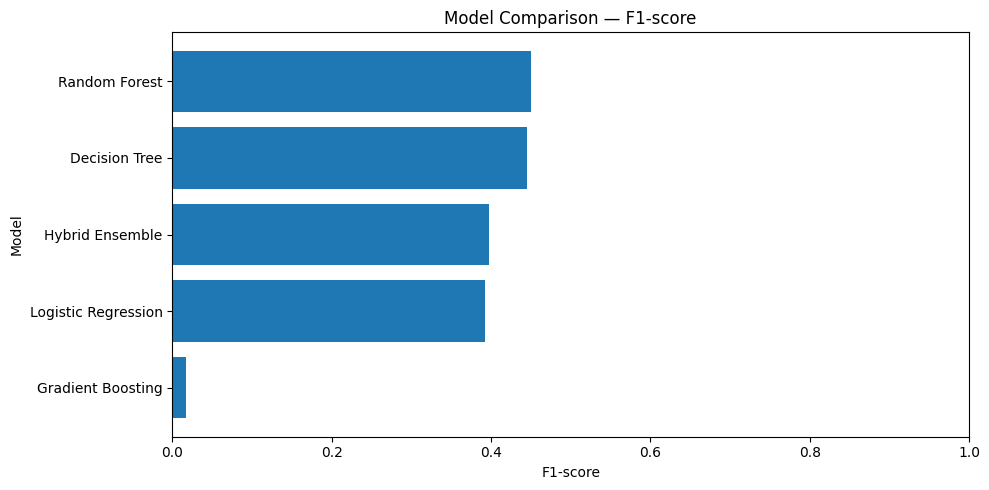

In [50]:
plt.figure(figsize=(10,5))
ordered = results.sort_values("F1", ascending=True)
plt.barh(ordered["Model"], ordered["F1"])
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.title("Model Comparison — F1-score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

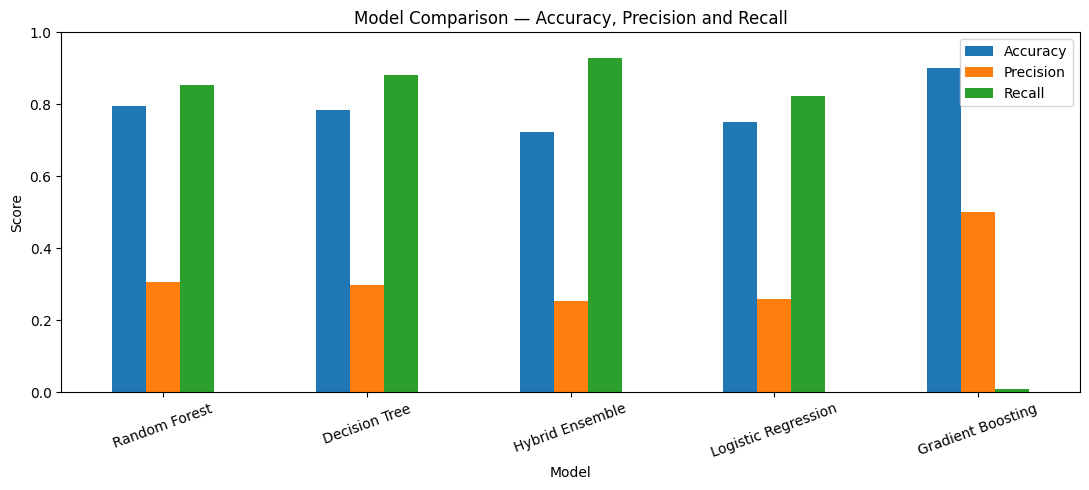

In [51]:
metric_plot = results.set_index("Model")[["Accuracy","Precision","Recall"]]
metric_plot.plot(kind="bar", figsize=(11,5))
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Model Comparison — Accuracy, Precision and Recall")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 16. Confusion matrix for the best F1 model

This is another easy result to explain:
- Top-left: correctly identified normal hours
- Bottom-right: correctly identified extreme hours
- Bottom-left: missed extreme hours
- Top-right: false alarms

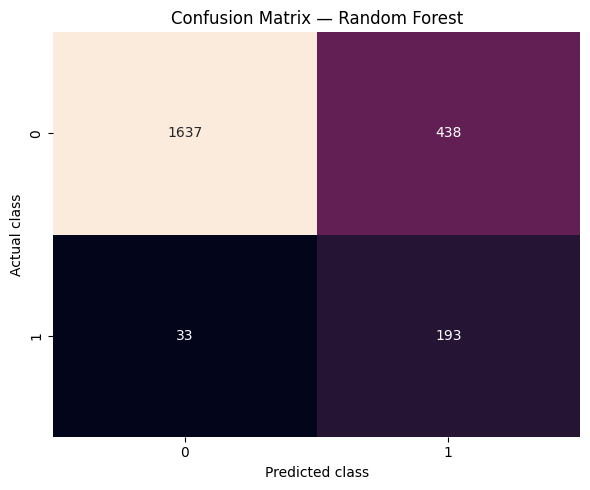

Best F1 model: Random Forest


In [52]:
best_model_name = results.iloc[0]["Model"]

if best_model_name == "Hybrid Ensemble":
    best_prediction = hybrid_prediction
else:
    best_prediction = models[best_model_name].predict(X_test)

cm = confusion_matrix(y_test, best_prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Confusion Matrix — " + best_model_name)
plt.tight_layout()
plt.show()

print("Best F1 model:", best_model_name)

## 17. Final research findings

The notebook supports five simple research conclusions:

1. **Demand scale is different across Mediterranean countries.**
2. **Demand variation is not uniform; some countries show wider ranges and stronger ramp stress.**
3. **Extreme demand is a minority event, so class-aware metrics are important.**
4. **Extreme hours can be studied as a regional synchronization problem, not only as a single-country forecasting problem.**
5. **Normal and hybrid machine-learning models can be compared on the new next-hour extreme-event target, giving a different modelling objective from the original PJME raw-load forecasting work.**

### Suggested viva explanation

> "Instead of only predicting the next numerical load value, our new research asks whether the next hour is likely to become an extreme-demand event. We compare simple and ensemble models, while also studying how extreme demand is distributed and synchronized across Mediterranean countries."

In [53]:
output_file = Path("Mediterranean_Research_Results_Model_Comparison.csv")
results.to_csv(output_file, index=False)
print("Saved model results to:", output_file.resolve())


Saved model results to: /content/Mediterranean_Research_Results_Model_Comparison.csv
